In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import math

### staggered grid

In [3]:

# mom6 needs staggered grid even in cartesian coord. 
Lx = 1000e3  # m
Ly = 400e3   # m
dx = 1000
dy = 1000
nx = int(Lx/dx)
ny = int(Ly/dy)
nxp = nx + 1  # For u-points
nyp = ny + 1  # For v-points

# Cell centers 
xh = np.linspace(dx/2, Lx - dx/2, nx)
yh = np.linspace(dy/2, Ly - dy/2, ny)

# Cell corners/edges (q-points)
xq = np.linspace(0, Lx, nxp)  # u is at eastern faces
yq = np.linspace(0, Ly, nyp)  # v is at northern faces

# Create meshgrids for computation
Xh, Yh = np.meshgrid(xh, yh)      # eta/h grid (ny, nx)
Xq, Yh_u = np.meshgrid(xq, yh)    # u grid (ny, nxp)
Xh_v, Yq = np.meshgrid(xh, yq)    # v grid (nyp, nx)

In [9]:
f = -1e-5
g = 9.81

### case of a tanh profile

In [133]:
U = 0.20      # m/s
Ljet = 10e3  # m
y0 = Ly/2    # m

yprime_h = (Yh - y0) / Ljet      # for eta
yprime_u = (Yh_u - y0) / Ljet    # for u
yprime_v = (Yq - y0) / Ljet      # for v

# 3. VELOCITY FIELDS (Bickley Jet) ON STAGGERED GRID
# u at (ny, nx+1) - eastern faces
u = U * np.tanh(yprime_u)

u_clean = u
# v at (ny+1, nx) - northern faces
v = np.zeros((ny+1, nx))

# Add small decaying noise to u
random_noise = np.random.randn(*u.shape)
decay_factor = 1 / np.cosh(yprime_u)**2   # sech^2
noise = 1e-3 * decay_factor * random_noise
u = u + noise

# 4. FREE SURFACE / THICKNESS FIELD
#f=2* 7.292e-5*math.sin(math.radians(-15))

In [134]:
u_noise = u-u_clean

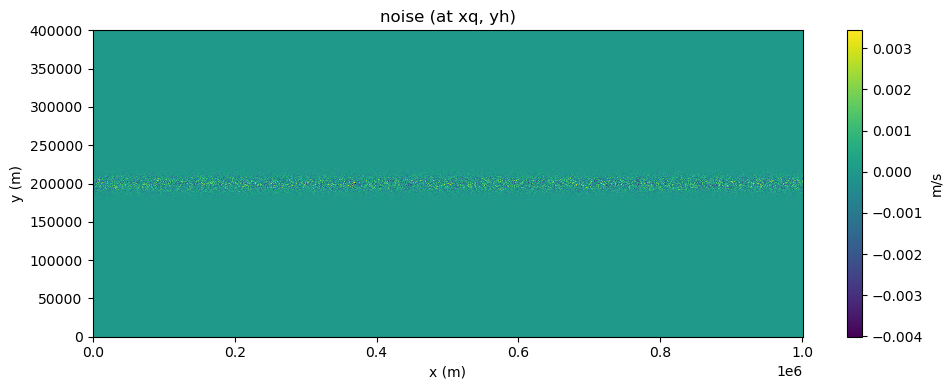

In [135]:
# PLOTTING
# Plot u
plt.figure(figsize=(10,4))
plt.title("noise (at xq, yh)")
plt.pcolormesh(Xq, Yh_u, u_noise, shading='auto')
plt.colorbar(label="m/s")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()

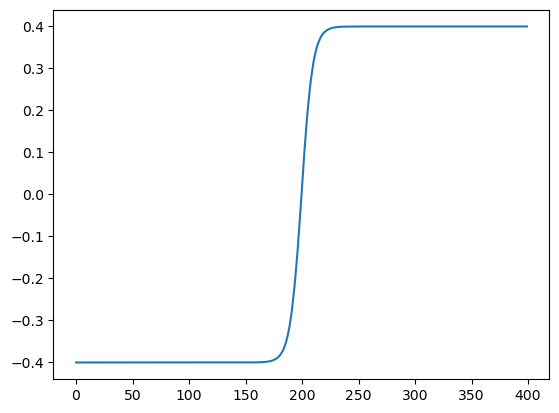

In [136]:
plt.plot(u[:,10])

In [137]:
eta_t = -(f * U * Ljet / g) * np.log(np.cosh(yprime_h))
eta_t = eta_t - eta_t.mean()


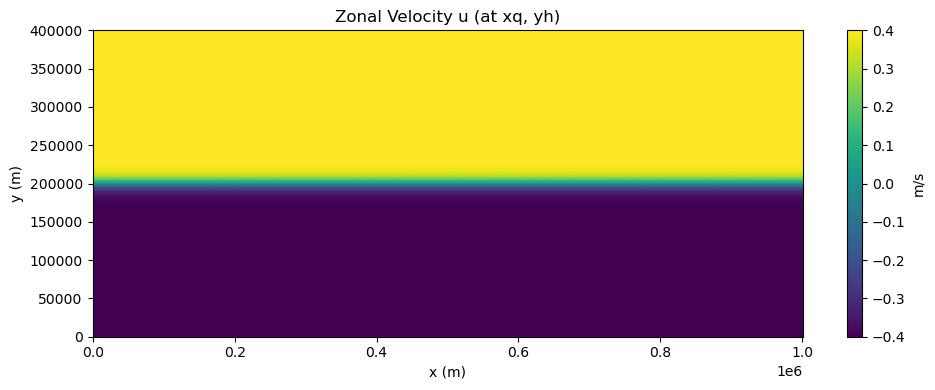

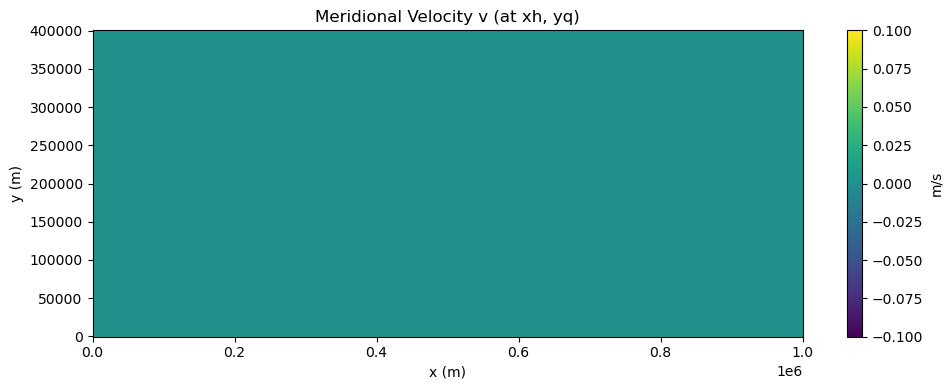

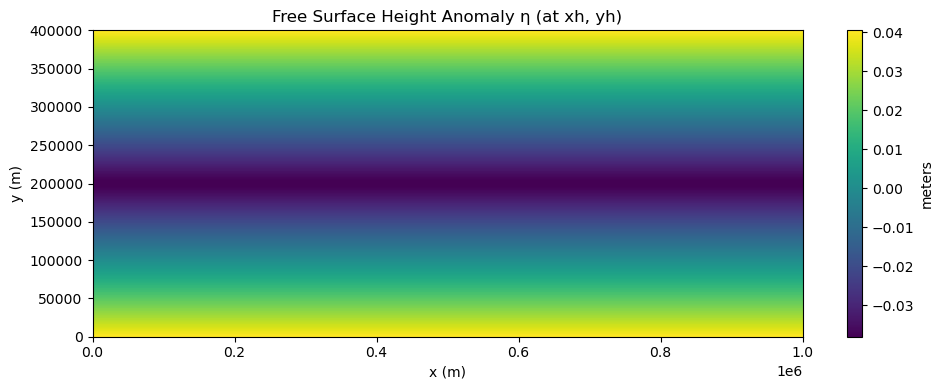

In [138]:

# PLOTTING
# Plot u
plt.figure(figsize=(10,4))
plt.title("Zonal Velocity u (at xq, yh)")
plt.pcolormesh(Xq, Yh_u, u, shading='auto')
plt.colorbar(label="m/s")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()

# Plot v
plt.figure(figsize=(10,4))
plt.title("Meridional Velocity v (at xh, yq)")
plt.pcolormesh(Xh_v, Yq, v, shading='auto')
plt.colorbar(label="m/s")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()

# Plot eta
plt.figure(figsize=(10,4))
plt.title("Free Surface Height Anomaly η (at xh, yh)")
plt.pcolormesh(xh, yh, eta_t, shading='auto')
plt.colorbar(label="meters")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()

In [139]:
u.shape

(400, 1001)

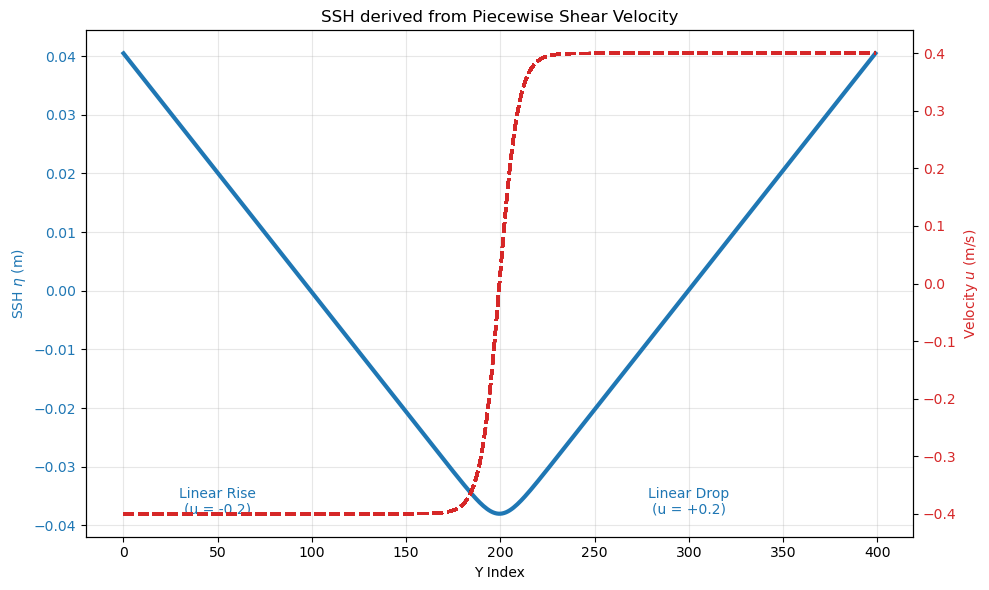

In [140]:
eta_1d = eta_t[:,10]
# ---------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot SSH (Blue)
color = 'tab:blue'
ax1.set_xlabel('Y Index')
ax1.set_ylabel('SSH $\eta$ (m)', color=color)
ax1.plot(eta_1d, color=color, linewidth=3, label='SSH ($\eta$)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Highlight the shape
ax1.text(50, np.min(eta_1d), "Linear Rise\n(u = -0.2)", color=color, ha='center')
ax1.text(300, np.min(eta_1d), "Linear Drop\n(u = +0.2)", color=color, ha='center')

# Plot Velocity (Red)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Velocity $u$ (m/s)', color=color)
ax2.plot(u, color=color, linestyle='--', linewidth=2, label='Velocity ($u$)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('SSH derived from Piecewise Shear Velocity')
fig.tight_layout()
plt.show()

In [141]:
# 6. WRITE VELOCITY FILE (velocity_uv.nc)
nc_vel = Dataset("/scratch/nm03/ae7501/mom6_input_directories/idealized/test41/INPUT/init_vel.nc", "w", format="NETCDF4")
# 7. WRITE THICKNESS FILE (thickness_h.nc)
nc_h = Dataset("/scratch/nm03/ae7501/mom6_input_directories/idealized/test41/INPUT/init_eta.nc", "w", format="NETCDF4")

In [142]:
# 5. ADD Z COORDINATE
zl = 1
layer_thickness = 500.0  # meters , not clear if i need the z dimention for the one layer model
z = np.array([-250.0])   # Single layer index
# Expand fields to (zl, y, x) with proper dimensions
h_3d = eta_t[np.newaxis, :, :]            # (1, ny, nx)
u_3d = u[np.newaxis, :, :]            # (1, ny, nxp)
v_3d = v[np.newaxis, :, :]            # (1, nyp, nx)



# Create dimensions
nc_vel.createDimension("zl", zl)
nc_vel.createDimension("yh", ny)
nc_vel.createDimension("xh", nx)
nc_vel.createDimension("yq", nyp)
nc_vel.createDimension("xq", nxp)

# Create coordinate variables (1D arrays)
zl_var = nc_vel.createVariable("zl", "f4", ("zl",))
zl_var[:] = z
zl_var.axis = "Z"
zl_var.long_name = "depth to layer"

xh_var = nc_vel.createVariable("xh", "f4", ("xh",))
xh_var[:] = xh
xh_var.axis = "X"
xh_var.long_name = "h-point longitude"
xh_var.units = "meters"

yh_var = nc_vel.createVariable("yh", "f4", ("yh",))
yh_var[:] = yh
yh_var.axis = "Y"
yh_var.long_name = "h-point latitude"
yh_var.units = "meters"

xq_var = nc_vel.createVariable("xq", "f4", ("xq",))
xq_var[:] = xq
xq_var.axis = "X"
xq_var.long_name = "q-point longitude"
xq_var.units = "meters"

yq_var = nc_vel.createVariable("yq", "f4", ("yq",))
yq_var[:] = yq
yq_var.axis = "Y"
yq_var.long_name = "q-point latitude"
yq_var.units = "meters"

# Create velocity variables
u_var = nc_vel.createVariable("u", "f4", ("zl", "yh", "xq"))
u_var[:] = u_3d
u_var.units = "m s-1"
u_var.long_name = "Eastward velocity"
u_var.standard_name = "eastward_sea_water_velocity"

v_var = nc_vel.createVariable("v", "f4", ("zl", "yq", "xh"))
v_var[:] = v_3d
v_var.units = "m s-1"
v_var.long_name = "Northward velocity"
v_var.standard_name = "northward_sea_water_velocity"

nc_vel.regrid_method = "bilinear"
nc_vel.close()

print(f"Created velocity_uv.nc")
print(f"  u: ({zl}, {ny}, {nxp}) at (zl, yh, xq)")
print(f"  v: ({zl}, {nyp}, {nx}) at (zl, yq, xh)")



# Create dimensions
nc_h.createDimension("yh", ny)
nc_h.createDimension("xh", nx)

# Create coordinate variables (1D arrays)
xh_var2 = nc_h.createVariable("xh", "f4", ("xh",))
xh_var2[:] = xh
xh_var2.axis = "X"
xh_var2.long_name = "h-point longitude"
xh_var2.units = "meters"

yh_var2 = nc_h.createVariable("yh", "f4", ("yh",))
yh_var2[:] = yh
yh_var2.axis = "Y"
yh_var2.long_name = "h-point latitude"
yh_var2.units = "meters"

# Create thickness variable
h_var = nc_h.createVariable("eta_t", "f4", ("yh", "xh"))
h_var[:] = h_3d
h_var.units = "m"
h_var.long_name = "Layer thickness"
h_var.standard_name = "sea_floor_depth_below_sea_surface"

nc_h.close()

print(f"Created thickness_h.nc")
print(f"  h: ({ny}, {nx}) at (yh, xh)")

print("Staggered grid setup complete!")
print(f"  Grid: {nx} × {ny} cells")
print(f"  h: at cell centers (xh, yh)")
print(f"  u: at eastern faces (xq, yh)")
print(f"  v: at northern faces (xh, yq)")

Created velocity_uv.nc
  u: (1, 400, 1001) at (zl, yh, xq)
  v: (1, 401, 1000) at (zl, yq, xh)
Created thickness_h.nc
  h: (400, 1000) at (yh, xh)
Staggered grid setup complete!
  Grid: 1000 × 400 cells
  h: at cell centers (xh, yh)
  u: at eastern faces (xq, yh)
  v: at northern faces (xh, yq)


## Bathymetry 

In [171]:

# Initialize depth array for y-axis
depth_profile_y = np.zeros(ny)

# 1. Depth drops from 100 to 100 between ny=0 and ny=190
depth_profile_y[0:175] = np.linspace(100, 100, 175) # (shallow_depth, deeper_Depth, no_of _indices_from_ny_start_to_end)

#Depth drops from 100 to 500 between ny=190 and ny=225--36 indices
# overlap at ny=190 to ensure continuity
depth_profile_y[175:225] = np.linspace(100, 500, 50)

# Depth is flat at 500 from ny=225 onwards
depth_profile_y[225:] = 500

# Create the 2D array by repeating the Y profile across the X dimension
# Shape will be (400, 1000)
depth_2d = np.tile(depth_profile_y[:, np.newaxis], (1, nx))

print(f"Shape: {depth_2d.shape}")


Shape: (400, 1000)


In [177]:
# 7. WRITE THICKNESS FILE (thickness_h.nc)
nc_d = Dataset("/scratch/nm03/ae7501/mom6_input_directories/idealized/test41/INPUT/ocean_topog.nc", "w", format="NETCDF4")
# Dimensions
nc_d.createDimension("yh", ny)
nc_d.createDimension("xh", nx)

xh_var = nc_d.createVariable("xh", "f4", ("xh",))
xh_var[:] = xh
xh_var.long_name = "t-cell center x-location"
xh_var.units = "meters"

yh_var = nc_d.createVariable("yh", "f4", ("yh",))
yh_var[:] = yh
yh_var.long_name = "t-cell center y-location"
yh_var.units = "meters"

# Topography variable
depth_var = nc_d.createVariable("depth", "f4", ("yh", "xh"))
depth_var[:] = depth_2d
depth_var.units = "m"
depth_var.long_name = "ocean bottom depth"
depth_var.standard_name = "sea_floor_depth_below_geoid"

nc_d.close()

print(" ocean_topog.nc written:")
print("shape =", depth_2d.shape, " = (ny, nx)")

 ocean_topog.nc written:
shape = (400, 1000)  = (ny, nx)
